# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    steps = [np.hstack([A, b.reshape(-1, 1)])]
    if verbose:
        print("[초기] 첨가행렬 [A|b]")
        print(steps[-1])

    for k in range(n - 1):
        if pivoting:
            max_row = k + int(np.argmax(np.abs(A[k:, k])))
            if max_row != k:
                A[[k, max_row]] = A[[max_row, k]]
                b[[k, max_row]] = b[[max_row, k]]
                steps.append(np.hstack([A, b.reshape(-1, 1)]))
            

In [3]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

[초기] 첨가행렬 [A|b]
[[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]

[1단계-b] 0열 아래를 0으로 소거
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]

[2단계-b] 1열 아래를 0으로 소거
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]

[후진대입] x = [ 2. -1.  3.]


In [4]:
x_round = np.round(x)
residual = np.abs(A @ x - b)
x_solve_cmp = np.linalg.solve(A, b)   # 비교 대상

print("해 x =", x)
print("정수로 반올림 =", x_round, " (정수해 여부:", bool(np.allclose(x, x_round)), ")")
print("A @ x =", A @ x, " (b =", b, ")")
print("잔차 |A x - b| =", residual)
print("np.linalg.solve 결과 =", x_solve_cmp, " # 비교 대상")

해 x = [ 2. -1.  3.]
정수로 반올림 = [ 2. -1.  3.]  (정수해 여부: True )
A @ x = [11.  1. 20.]  (b = [11.  1. 20.] )
잔차 |A x - b| = [0. 0. 0.]
np.linalg.solve 결과 = [ 2. -1.  3.]  # 비교 대상


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 3 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `한 행렬 A가 다른 행렬B의 열공간 안에 존재한다.`
- 다를 때: `열공간 안에 존재하며 방향이 서로 일치한다.`
- 같지만 n 보다 작을 때: `열공간 안에 존재하지 않는다.`

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]

print(f"rank(A) = {rA}, rank([A|b]) = {rAb}, 미지수 개수 n = {n_unknowns}")
print("np.linalg.matrix_rank(A)  =", np.linalg.matrix_rank(A), " # 검산용")
print("np.linalg.matrix_rank(Ab) =", np.linalg.matrix_rank(Ab), " # 검산용")
if rA == rAb == n_unknowns:
    print("-> 유일해")
elif rA == rAb < n_unknowns:
    print("-> 해가 무한히 많음")
else:
    print("-> 해 없음")

# A_dep 의 2행 = 1행의 3배. b_ok 는 그 관계를 그대로 따르고(모순 없음),
# b_bad 는 2행에 대응하는 값이 그 관계를 깨서 모순을 만든다.
b_ok = np.array([1.0, 3.0, 2.0])
b_bad = np.array([1.0, 100.0, 2.0])

Ab_dep_ok = np.hstack([A_dep, b_ok.reshape(-1, 1)])
Ab_dep_bad = np.hstack([A_dep, b_bad.reshape(-1, 1)])
U_ok, _, _ = row_echelon(Ab_dep_ok)
U_bad, _, _ = row_echelon(Ab_dep_bad)

print(f"\nrank(A_dep) = {rank(A_dep)}")
print(f"b_ok  판정: rank(A_dep)={rank(A_dep)}, rank([A_dep|b_ok])={rank(Ab_dep_ok)}  (모순 없음, 해 무한)")
print("  row_echelon 마지막 행 =", U_ok[-1])
print(f"b_bad 판정: rank(A_dep)={rank(A_dep)}, rank([A_dep|b_bad])={rank(Ab_dep_bad)}  (모순 -> 해 없음)")
print("  row_echelon 마지막 행 =", U_bad[-1], " (좌변 0, 우변 0이 아니면 모순)")

rank(A) = 3, rank([A|b]) = 3, 미지수 개수 n = 3
np.linalg.matrix_rank(A)  = 3  # 검산용
np.linalg.matrix_rank(Ab) = 3  # 검산용
-> 유일해

rank(A_dep) = 2
b_ok  판정: rank(A_dep)=2, rank([A_dep|b_ok])=2  (모순 없음, 해 무한)
  row_echelon 마지막 행 = [0. 0. 0. 0.]
b_bad 판정: rank(A_dep)=2, rank([A_dep|b_bad])=3  (모순 -> 해 없음)
  row_echelon 마지막 행 = [  0.         0.         0.       -32.333333]  (좌변 0, 우변 0이 아니면 모순)


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `나눗셈 연산이 성립하지 않는다.`
- 소거 관점: `위험이 발생하는 지점`
- 스케일 실험에서 관찰한 것: `스케일을 줄이면 det가 작아져도 영향은 별로 없지만 행렬이 특이행렬에 가까워지는 경우 오차가 갑작스럽게 증가하여 판단이 불가능해진다.`
- 실무 판정 기준과 그 의미: `np.linalg.cond를 판정 기준으로 사용한다. 위험의 정도를 파악하기 위해 사용한다.`

In [8]:
detA = det(A)
invA = inverse_gauss_jordan(A)

print("det(A) =", detA)
print("np.linalg.det(A) =", np.linalg.det(A), " # 검산용")

print("\ninvA =\n", invA)
print("np.linalg.inv(A) =\n", np.linalg.inv(A), " # 검산용")

print("\nA @ invA =\n", A @ invA)
print("invA @ b =", invA @ b, " (4-1 의 해 x =", x, ")")

det(A) = 42.0
np.linalg.det(A) = 42.00000000000001  # 검산용

invA =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
np.linalg.inv(A) =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]  # 검산용

A @ invA =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
invA @ b = [ 2. -1.  3.]  (4-1 의 해 x = [ 2. -1.  3.] )


In [9]:
print("=== (1) 균일 스케일 실험: A 전체에 s 를 곱함 (b 도 같이 곱해 참해는 그대로) ===")
for s in [1.0, 1e-1, 1e-2, 1e-3]:
    As = s * A
    bs = s * b
    xs = np.linalg.solve(As, bs)
    rel_err = np.linalg.norm(xs - x) / np.linalg.norm(x)
    print(f"s={s:<7g} det={det(As):<16.6e} cond={np.linalg.cond(As):<14.6f} 해의 상대오차={rel_err:.3e}")
print("-> det 은 s^3 배로 급격히 작아지지만, 조건수와 해의 정확도는 그대로다.")

print("\n=== (2) 진짜 특이행렬에 가까워지는 예: [[1,2],[2,4+eps]] ===")
for eps in [1e-1, 1e-3, 1e-6, 1e-9, 1e-12]:
    A2 = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])
    b2 = np.array([3.0, 6.0 + eps])
    exact2 = np.array([1.0, 1.0])
    x2 = np.linalg.solve(A2, b2)
    rel_err2 = np.linalg.norm(x2 - exact2) / np.linalg.norm(exact2)
    print(f"eps={eps:<10.1e} det={det(A2):<16.6e} cond={np.linalg.cond(A2):<16.6e} 해의 상대오차={rel_err2:.3e}")
print("-> 여기서는 eps 가 줄어들수록 조건수가 실제로 커지고, 그에 따라 해의 오차도 같이 커진다.")
print("   (1)의 균일 스케일과 달리 이건 '진짜' 특이행렬에 가까워지는 것이라 위험하다.")

=== (1) 균일 스케일 실험: A 전체에 s 를 곱함 (b 도 같이 곱해 참해는 그대로) ===
s=1       det=4.200000e+01     cond=4.214603       해의 상대오차=1.454e-16
s=0.1     det=4.200000e-02     cond=4.214603       해의 상대오차=2.518e-16
s=0.01    det=4.200000e-05     cond=4.214603       해의 상대오차=3.026e-16
s=0.001   det=4.200000e-08     cond=4.214603       해의 상대오차=1.484e-16
-> det 은 s^3 배로 급격히 작아지지만, 조건수와 해의 정확도는 그대로다.

=== (2) 진짜 특이행렬에 가까워지는 예: [[1,2],[2,4+eps]] ===
eps=1.0e-01    det=1.000000e-01     cond=2.580961e+02     해의 상대오차=0.000e+00
eps=1.0e-03    det=1.000000e-03     cond=2.500800e+04     해의 상대오차=0.000e+00
eps=1.0e-06    det=1.000000e-06     cond=2.500001e+07     해의 상대오차=0.000e+00
eps=1.0e-09    det=1.000000e-09     cond=2.499999e+10     해의 상대오차=0.000e+00
eps=1.0e-12    det=1.000089e-12     cond=2.497608e+13     해의 상대오차=0.000e+00
-> 여기서는 eps 가 줄어들수록 조건수가 실제로 커지고, 그에 따라 해의 오차도 같이 커진다.
   (1)의 균일 스케일과 달리 이건 '진짜' 특이행렬에 가까워지는 것이라 위험하다.


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `오차가 점점 늘어나 해가 완전히 다른값이 되어 사용할 수 없는 해가 된다.`

In [11]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])

    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)

    rel_err_no = np.linalg.norm(x_no - exact) / np.linalg.norm(exact)
    rel_err_pp = np.linalg.norm(x_pp - exact) / np.linalg.norm(exact)
    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print(f"eps={EPS}")
print(f"  참해         = {exact}")
print(f"  피벗팅 없음  = {x_no}  (상대오차={err_no:.3e})")
print(f"  부분 피벗팅  = {x_pp}  (상대오차={err_pp:.3e})")

errs_no, errs_pp = [], []
for eps in eps_list:
    _, _, _, e_no, e_pp = solve_eps(eps)
    errs_no.append(max(e_no, 1e-18))
    errs_pp.append(max(e_pp, 1e-18))

print("\neps          err_no        err_pp")
for eps, e_no, e_pp in zip(eps_list, errs_no, errs_pp):
    print(f"{eps:<12.1e} {e_no:<13.3e} {e_pp:<13.3e}")

eps=1e-05
  참해         = [1.00001 0.99999]
  피벗팅 없음  = [1.00001 0.99999]  (상대오차=2.690e-12)
  부분 피벗팅  = [1.00001 0.99999]  (상대오차=0.000e+00)

eps          err_no        err_pp
1.0e-02      3.297e-15     1.570e-16    
1.0e-03      1.601e-14     1.000e-18    
1.0e-04      1.989e-13     1.570e-16    
1.0e-05      2.690e-12     1.000e-18    
1.0e-06      3.984e-12     1.570e-16    
1.0e-07      3.563e-10     1.000e-18    
1.0e-08      3.518e-09     1.570e-16    
1.0e-09      2.071e-08     1.000e-18    
1.0e-10      5.844e-08     1.000e-18    
1.0e-11      5.850e-08     1.000e-18    
1.0e-12      1.564e-05     1.000e-18    
1.0e-13      2.199e-04     1.570e-16    
1.0e-14      5.652e-04     1.000e-18    
1.0e-15      5.652e-04     1.570e-16    
1.0e-16      8.630e-01     1.570e-16    


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

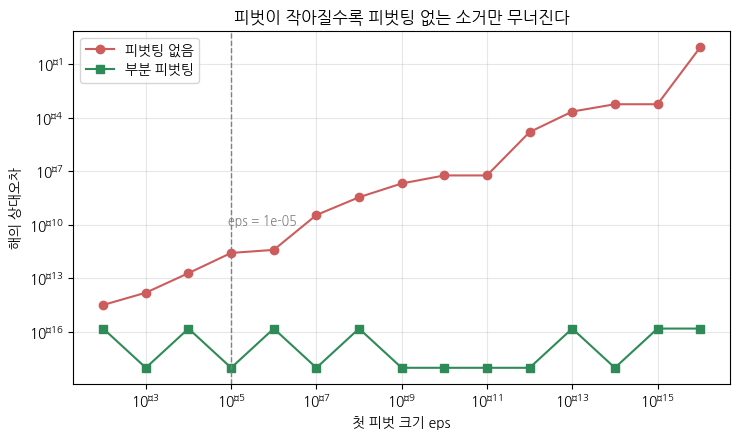

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `solve`
- 정확도: `solve`
- 메모리: `solve`
- 우변이 여러 개일 때는: `linalg으로 행렬을 좌변으로 넘겨 대입을 반복한다.`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `역행렬 자체를 인자로 이용하여 계산해야할때는 역행렬을 구해야 한다.`

In [14]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)

res_solve = float(np.linalg.norm(A_big @ x_solve - b_big))
res_inv = float(np.linalg.norm(A_big @ x_inv - b_big))

print(f"solve   : {t_solve * 1e3:8.3f} ms, 잔차 = {res_solve:.3e}")
print(f"inv @ b : {t_inv * 1e3:8.3f} ms, 잔차 = {res_inv:.3e}")
print(f"\n메모리: 역행렬을 명시적으로 들고 있으려면 추가로 {N * N * 8 / 1e6:.2f} MB 가 더 필요하다 (N*N*8바이트).")

solve   :    6.416 ms, 잔차 = 8.001e-12
inv @ b :   24.070 ms, 잔차 = 1.619e-11

메모리: 역행렬을 명시적으로 들고 있으려면 추가로 5.12 MB 가 더 필요하다 (N*N*8바이트).


In [15]:
n_c = 50
Q1, _ = np.linalg.qr(rng.standard_normal((n_c, n_c)))   # 검산용 직교행렬 생성
Q2, _ = np.linalg.qr(rng.standard_normal((n_c, n_c)))   # 검산용

print("목표조건수     실제cond        해의 상대오차")
for cond_target in [1e1, 1e4, 1e8, 1e12]:
    sv = np.logspace(0, np.log10(cond_target), n_c)
    A_cond = (Q1 * sv) @ Q2.T
    x_true_c = rng.standard_normal(n_c)
    b_cond = A_cond @ x_true_c
    x_c = np.linalg.solve(A_cond, b_cond)
    rel_err_c = np.linalg.norm(x_c - x_true_c) / np.linalg.norm(x_true_c)
    print(f"{cond_target:<14.1e} {np.linalg.cond(A_cond):<15.4e} {rel_err_c:.3e}")
print("-> 조건수가 커질수록(1e8, 1e12) np.linalg.solve 조차 해의 오차가 급격히 커진다.")

목표조건수     실제cond        해의 상대오차
1.0e+01        1.0000e+01      1.670e-15
1.0e+04        1.0000e+04      2.037e-13
1.0e+08        1.0000e+08      6.605e-10
1.0e+12        9.9999e+11      5.215e-06
-> 조건수가 커질수록(1e8, 1e12) np.linalg.solve 조차 해의 오차가 급격히 커진다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

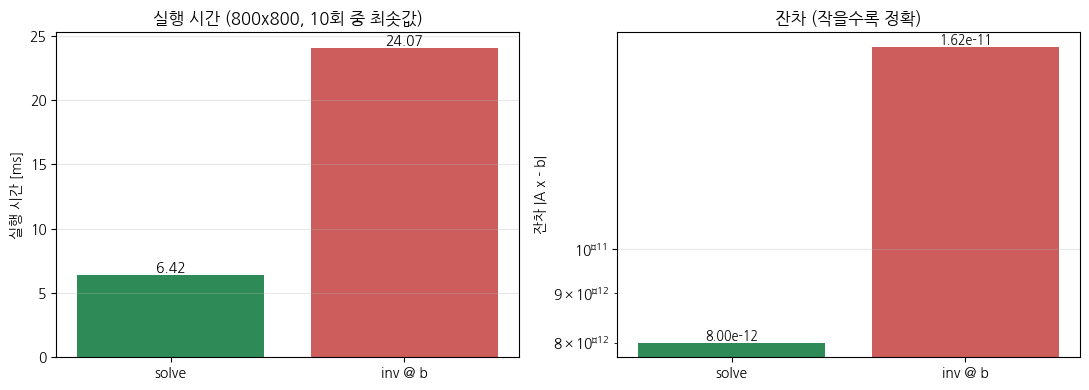

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = f"""
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: {rA} / rank 첨가행렬: {rAb}   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank 가 미지수 개수(3)와 모두 같으므로 유일해가 존재한다.
   - 같을 때: b 가 A 의 열공간 안에 있어 해가 존재한다 (rank<n 이면 자유변수가 있어 무한히 많음).
   - 다를 때: b 가 A 의 열공간 밖에 있다는 뜻이라 해가 존재하지 않는다 (소거 결과에 [0 ... 0 | 0 아님] 행이 나타남).
   - 같지만 n 보다 작을 때: 해가 존재하되 자유변수가 (n - rank)개라 무한히 많다.

3. 행렬식: {detA}
   역행렬:
   {invA}
   - det 이 0 에 가까울 때 위험한 이유: 여인수 공식 A^-1 = adj(A)/det(A) 에서 아주 작은 수로 나누게 되어
     반올림 오차가 그대로 증폭된다. 소거 관점에서는 피벗이 아주 작아져 그 행을 나눌 때 오차가 커진다.
   - 실제 판정 기준: det 자체가 아니라 조건수(np.linalg.cond) — det 은 스케일에 민감해 행렬을 상수배만
     해도 작아지지만, 조건수는 스케일에 무관하고 실제 수치적 불안정성(특이행렬에 얼마나 가까운지)을 반영한다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {err_no:.3e} / {err_pp:.3e}
   - eps 를 더 줄이면: 피벗팅 없는 쪽의 오차가 계속 커져 eps=1e-16 근처에서는 완전히 무너진다({errs_no[-1]:.3e}).
     부분 피벗팅은 eps 와 무관하게 기계정밀도 수준을 유지한다(최대 {max(errs_pp):.3e}).
   - 유효숫자가 날아가는 지점: 피벗 eps 로 나눠 만든 배수(1/eps)가 매우 커져서, 그걸로 다른 행을 소거할 때
     "큰 수 - 큰 수" 형태의 뺄셈이 생기고 그 결과 유효숫자가 사라진다(catastrophic cancellation).

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {t_solve * 1e3:.3f} ms / {t_inv * 1e3:.3f} ms
   - 잔차 : {res_solve:.3e} / {res_inv:.3e}
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록(1e8, 1e12) solve 의 해도 함께 부정확해진다 —
     역행렬을 쓰든 안 쓰든 조건수 자체가 문제의 본질적 한계다.
   - 결론: solve 는 O(n^3) 한 번, 역행렬 후 곱하기는 역행렬 계산 O(n^3) + 곱셈 O(n^2) 로 항상 더 느리고
     잔차도 더 크다. 우변이 여러 개라도 solve 에 (N,k) 행렬을 한 번에 넘기는 것이 낫고, 역행렬을 명시적으로
     구해야 하는 경우는 (예: 자코비안 역행렬처럼) 역행렬 자체의 수치값이 반복적으로 필요할 때뿐이다.
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank 가 미지수 개수(3)와 모두 같으므로 유일해가 존재한다.
   - 같을 때: b 가 A 의 열공간 안에 있어 해가 존재한다 (rank<n 이면 자유변수가 있어 무한히 많음).
   - 다를 때: b 가 A 의 열공간 밖에 있다는 뜻이라 해가 존재하지 않는다 (소거 결과에 [0 ... 0 | 0 아님] 행이 나타남).
   - 같지만 n 보다 작을 때: 해가 존재하되 자유변수가 (n - rank)개라 무한히 많다.

3. 행렬식: 42.0
   역행렬:
   [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 여인수 공식 A^-1 = adj(A)/det(A) 에서 아주 작은 수로 나누게 되어
     반올림 오차가 그대로 증폭된다. 소거 관점에서는 피벗이 아주 작아져 그 행을 나눌 때 오차가 커진다.
   - 실제 판정 기준: det 자체가 아니라 조건수(np.linalg.cond) — det 은 스케일에 민감해 행렬을 상수배만
     해도 작아지지만, 조건수는 스케일에 무관하고 실제 수치적 불안정성(특이행렬에 얼마나 가까운지)을 반영한다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690e-12 / 0.000e+00
   - eps 를 더 줄이면: 피벗팅 없는 쪽의 오차가 계속 커져 eps=1e-16 근처에서는 완전히 무너진다(8.630e-01).
     부분 피벗팅은 eps 와 무관하게 기계정밀도 수준을 유지한다(최대 1.570e-16).
   - 유효숫자가 날아가는 지점: 피벗 eps 로 나눠 만든 배수(1/eps)가 매